# RFID-Based Yoga Arm Pose Classifier

Classifies five arm poses using passive UHF RFID data from an **Impinj Speedway R420** reader with a single antenna and **3 body-worn tags**.

**Poses:** `armsdown`, `armsmiddle`, `armsup`, `lefthandup`, `righthandup`

**Pipeline overview:**
1. Load & parse Impinj CSV files — 5 files per pose, flat folder
2. Split automatically: files 1–4 → train, file 5 (last by filename) → test
3. Per-tag feature extraction over sliding windows
4. Train + cross-validate Random Forest, SVM, MLP, Gradient Boosting
5. Evaluate best model on the held-out test trial
6. Confusion matrix + feature importance visualisation

---

## Expected folder layout
```
data/
  armsdown/        <- 5 x *.csv  (no train/ test/ subfolders needed)
  armsmiddle/
  armsup/
  lefthandup/
  righthandup/
```
Files are sorted alphabetically; the **last file per pose is held out as test**, the first four are training.
Change `TEST_FILE_INDEX` in the config cell if you want a different split.

Each CSV is a raw Impinj log with `//`-commented header lines followed by comma-separated rows:
`Timestamp, EPC, TID, Antenna, RSSI, Frequency, Hostname, PhaseAngle, DopplerFrequency, CRHandle`

## 0 · Dependencies

In [1]:
import subprocess, sys
pkgs = ["pandas", "numpy", "scikit-learn", "matplotlib", "seaborn", "scipy"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])

CompletedProcess(args=['c:\\Anaconda3\\envs\\info5304\\python.exe', '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'scipy'], returncode=0)

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42
print("All imports OK")

All imports OK


## 1 · Configuration

In [3]:
# ── Point this at your data folder ────────────────────────────────────────────
DATA_ROOT = Path("data")      # e.g. Path("/home/user/rfid_yoga/data")

POSES = ["armsdown", "armsmiddle", "armsup", "lefthandup", "righthandup"]

# Column names for the Impinj Speedway CSV (after skipping '//' comment lines)
COL_NAMES = [
    "Timestamp", "EPC", "TID", "Antenna",
    "RSSI", "Frequency", "Hostname",
    "PhaseAngle", "DopplerFrequency", "CRHandle"
]

# Which file index to hold out as test (Python indexing, so -1 = last file)
TEST_FILE_INDEX = -1

# Feature extraction window
WINDOW_SEC = 2.0   # window length in seconds
STEP_SEC   = 1.0   # step / hop   (50% overlap)

# Set to a list of full EPC strings to pin specific tags; None = use all
TAG_FILTER = None

print(f"Data root       : {DATA_ROOT.resolve()}")
print(f"Poses           : {POSES}")
print(f"Window          : {WINDOW_SEC}s  step {STEP_SEC}s")
print(f"Test file index : {TEST_FILE_INDEX}  (per pose)")

Data root       : C:\Users\Colette D'Costa\INFO 6432\data
Poses           : ['armsdown', 'armsmiddle', 'armsup', 'lefthandup', 'righthandup']
Window          : 2.0s  step 1.0s
Test file index : -1  (per pose)


## 2 · Data Loading

In [4]:
def load_rfid_csv(path):
    """Parse a single Impinj Speedway CSV, skipping '//' comment lines."""
    df = pd.read_csv(
        Path(path), comment="/", names=COL_NAMES,
        dtype={"EPC": str, "TID": str},
    )
    df.dropna(subset=["EPC", "RSSI"], inplace=True)
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
    df.sort_values("Timestamp", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def split_pose_files(pose):
    """Return (train_paths, test_path) for a pose folder."""
    csvs = sorted((DATA_ROOT / pose).glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSVs in {DATA_ROOT / pose}")
    test_path   = csvs[TEST_FILE_INDEX]
    train_paths = [p for p in csvs if p != test_path]
    return train_paths, test_path


# Inventory
print(f"{'Pose':<16} {'Train files':<55} Test file")
print("-" * 100)
for pose in POSES:
    try:
        tr, te = split_pose_files(pose)
        print(f"{pose:<16} {', '.join(p.name for p in tr):<55} {te.name}")
    except FileNotFoundError as e:
        print(f"{pose:<16} *** {e} ***")

Pose             Train files                                             Test file
----------------------------------------------------------------------------------------------------
armsdown         test_2026-04-27_13-10-02.csv, test_2026-04-27_13-10-35.csv, test_2026-04-27_13-11-07.csv, test_2026-04-27_13-11-42.csv test_2026-04-27_13-12-14.csv
armsmiddle       test_2026-04-27_13-13-17.csv, test_2026-04-27_13-13-52.csv, test_2026-04-27_13-14-35.csv, test_2026-04-27_13-15-09.csv test_2026-04-27_13-16-11.csv
armsup           test_2026-04-27_13-05-35.csv, test_2026-04-27_13-06-25.csv, test_2026-04-27_13-07-04.csv, test_2026-04-27_13-07-43.csv test_2026-04-27_13-08-20.csv
lefthandup       test_2026-04-27_13-24-26.csv, test_2026-04-27_13-24-57.csv, test_2026-04-27_13-26-17.csv, test_2026-04-27_13-26-49.csv test_2026-04-27_13-27-23.csv
righthandup      test_2026-04-27_13-20-15.csv, test_2026-04-27_13-21-23.csv, test_2026-04-27_13-21-55.csv, test_2026-04-27_13-22-55.csv test_2026-04-27_13-2

In [5]:
# Quick sanity-check on one file
first_paths, _ = split_pose_files(POSES[0])
sample = load_rfid_csv(first_paths[0])
dur = (sample["Timestamp"].iloc[-1] - sample["Timestamp"].iloc[0]).total_seconds()
print(f"Rows       : {len(sample)}")
print(f"Tags (EPC) : {sample['EPC'].unique().tolist()}")
print(f"Duration   : {dur:.1f}s")
print(f"Read rate  : {len(sample)/dur:.0f} reads/s")
sample.head(3)

Rows       : 1470
Tags (EPC) : ['1A0F0778EF09A53072D24C63', '111111111111111111111112', '111111111111111111111111']
Duration   : 30.2s
Read rate  : 49 reads/s


,Timestamp,EPC,TID,Antenna,RSSI,Frequency,Hostname,PhaseAngle,DopplerFrequency,CRHandle
0,2026-04-27 17:30:46.251618+00:00,1A0F0778EF09A53072D24C63,E28011B02000B041832C03B9,1,-66.0,910.75,speedwayr-14-76-11.local,4.706253,NaN,NaN
1,2026-04-27 17:30:46.252718+00:00,111111111111111111111112,E28011912000786CDC610311,1,-46.5,910.75,speedwayr-14-76-11.local,4.884195,NaN,NaN
2,2026-04-27 17:30:46.253828+00:00,111111111111111111111111,E28011912000786DDC610311,1,-56.5,910.75,speedwayr-14-76-11.local,2.718214,NaN,NaN


## 3 · Feature Extraction

For each window we compute the following **per-tag** statistics:

| Feature | Description |
|---|---|
| `rssi_mean` | Mean received signal strength |
| `rssi_std` | RSSI variability |
| `rssi_min`, `rssi_max` | Range anchors |
| `rssi_range` | Peak-to-peak amplitude |
| `rssi_iqr` | Interquartile range (robust spread) |
| `rssi_skew`, `rssi_kurt` | Higher-order RSSI moments |
| `read_rate` | Tag reads per second |
| `phase_mean`, `phase_std` | Phase angle statistics |
| `phase_range` | Phase sweep extent |
| `phase_sin_mean`, `phase_cos_mean` | Circular mean (wrap-safe) |

Features are concatenated across all 3 tags → **42-element feature vector** per window.

In [6]:
_FEAT_KEYS = [
    "rssi_mean", "rssi_std", "rssi_min", "rssi_max", "rssi_range",
    "rssi_iqr", "rssi_skew", "rssi_kurt", "read_rate",
    "phase_mean", "phase_std", "phase_range", "phase_sin_mean", "phase_cos_mean"
]


def window_features(group, window_sec):
    rssi  = group["RSSI"].values.astype(float)
    phase = group["PhaseAngle"].dropna().values.astype(float)
    n = len(rssi)
    feats = {
        "rssi_mean"  : np.mean(rssi),
        "rssi_std"   : np.std(rssi)   if n > 1 else 0.0,
        "rssi_min"   : np.min(rssi),
        "rssi_max"   : np.max(rssi),
        "rssi_range" : np.ptp(rssi),
        "rssi_iqr"   : float(np.percentile(rssi, 75) - np.percentile(rssi, 25)) if n > 1 else 0.0,
        "rssi_skew"  : float(stats.skew(rssi))     if n > 2 else 0.0,
        "rssi_kurt"  : float(stats.kurtosis(rssi)) if n > 3 else 0.0,
        "read_rate"  : n / window_sec,
    }
    if len(phase) > 0:
        feats["phase_mean"]     = np.mean(phase)
        feats["phase_std"]      = np.std(phase)  if len(phase) > 1 else 0.0
        feats["phase_range"]    = np.ptp(phase)  if len(phase) > 1 else 0.0
        feats["phase_sin_mean"] = np.mean(np.sin(phase))
        feats["phase_cos_mean"] = np.mean(np.cos(phase))
    else:
        feats.update({"phase_mean": 0.0, "phase_std": 0.0, "phase_range": 0.0,
                      "phase_sin_mean": 0.0, "phase_cos_mean": 0.0})
    return feats


def extract_windows(df, label, window_sec=WINDOW_SEC, step_sec=STEP_SEC,
                    known_tags=None):
    """
    Slide a window over one trial and return a wide-format feature DataFrame.
    known_tags pins the canonical tag order; pass the training tag list when
    processing the test file to guarantee identical column layout.
    """
    t0  = df["Timestamp"].iloc[0]
    dur = (df["Timestamp"].iloc[-1] - t0).total_seconds()
    tags = known_tags if known_tags is not None else sorted(df["EPC"].unique())
    if TAG_FILTER:
        tags = [t for t in tags if t in TAG_FILTER]

    rows = []
    win_start = 0.0
    while win_start + window_sec <= dur:
        t_lo   = t0 + pd.Timedelta(seconds=win_start)
        t_hi   = t0 + pd.Timedelta(seconds=win_start + window_sec)
        win_df = df[(df["Timestamp"] >= t_lo) & (df["Timestamp"] < t_hi)]
        row = {}
        for tag in tags:
            pfx = tag[:8]
            tdf = win_df[win_df["EPC"] == tag]
            if len(tdf) == 0:
                row.update({f"{pfx}_{k}": 0.0 for k in _FEAT_KEYS})
            else:
                row.update({f"{pfx}_{k}": v
                            for k, v in window_features(tdf, window_sec).items()})
        row["label"] = label
        rows.append(row)
        win_start += step_sec
    return pd.DataFrame(rows)


sample_feats = extract_windows(sample, POSES[0])
print(f"Windows per trial : {len(sample_feats)}")
print(f"Features per row  : {sample_feats.shape[1] - 1}")
sample_feats.head(2)

Windows per trial : 29
Features per row  : 28


,11111111_rssi_mean,11111111_rssi_std,11111111_rssi_min,11111111_rssi_max,11111111_rssi_range,11111111_rssi_iqr,11111111_rssi_skew,11111111_rssi_kurt,11111111_read_rate,11111111_phase_mean,...,1A0F0778_rssi_iqr,1A0F0778_rssi_skew,1A0F0778_rssi_kurt,1A0F0778_read_rate,1A0F0778_phase_mean,1A0F0778_phase_std,1A0F0778_phase_range,1A0F0778_phase_sin_mean,1A0F0778_phase_cos_mean,label
0,-45.602941,1.566090,-48.0,-43.0,5.0,2.375,0.317122,-1.241363,17.0,2.891464,...,2.0,-0.074080,-0.848329,17.0,3.512816,1.971371,5.761632,-0.207911,0.209083,armsdown
1,-45.393939,1.423598,-47.0,-43.0,4.0,2.500,0.391835,-1.460086,16.5,2.877934,...,2.0,-0.589384,-0.001414,16.5,3.448575,1.933598,5.632777,-0.049914,0.179333,armsdown


## 4 · Build Train & Test Datasets

In [7]:
def build_datasets():
    # --- Pass 1: load all raw DataFrames, discover canonical tags ---
    raw_train, raw_test = {}, {}
    all_train_tags = set()
    for pose in POSES:
        try:
            tr_paths, te_path = split_pose_files(pose)
        except FileNotFoundError as e:
            print(f"[WARNING] {e}")
            continue
        raw_train[pose] = [load_rfid_csv(p) for p in tr_paths]
        raw_test[pose]  = load_rfid_csv(te_path)
        for df in raw_train[pose]:
            all_train_tags.update(df["EPC"].unique())

    canonical_tags = sorted(all_train_tags)
    if TAG_FILTER:
        canonical_tags = [t for t in canonical_tags if t in TAG_FILTER]
    print(f"Canonical tags ({len(canonical_tags)}): {canonical_tags}\n")

    # --- Pass 2: extract windows ---
    train_frames, test_frames = [], []
    for pose in POSES:
        if pose not in raw_train:
            continue
        tr_windows = 0
        for i, df in enumerate(raw_train[pose]):
            feat_df = extract_windows(df, label=pose, known_tags=canonical_tags)
            feat_df["trial"] = i
            train_frames.append(feat_df)
            tr_windows += len(feat_df)

        feat_df = extract_windows(raw_test[pose], label=pose, known_tags=canonical_tags)
        feat_df["trial"] = TEST_FILE_INDEX
        test_frames.append(feat_df)

        print(f"  {pose:<14}: {len(raw_train[pose])} train trials "
              f"({tr_windows} windows) | 1 test trial ({len(feat_df)} windows)")

    return (pd.concat(train_frames, ignore_index=True),
            pd.concat(test_frames,  ignore_index=True),
            canonical_tags)


train_df, test_df, CANONICAL_TAGS = build_datasets()
print(f"\nTotal train : {len(train_df)} windows")
print(f"Total test  : {len(test_df)} windows")

Canonical tags (3): ['111111111111111111111111', '111111111111111111111112', '1A0F0778EF09A53072D24C63']

  armsdown      : 4 train trials (115 windows) | 1 test trial (29 windows)
  armsmiddle    : 4 train trials (114 windows) | 1 test trial (29 windows)
  armsup        : 4 train trials (115 windows) | 1 test trial (28 windows)
  lefthandup    : 4 train trials (115 windows) | 1 test trial (29 windows)
  righthandup   : 4 train trials (116 windows) | 1 test trial (29 windows)

Total train : 575 windows
Total test  : 144 windows


In [8]:
FEATURE_COLS = [c for c in train_df.columns if c not in ("label", "trial")]

le = LabelEncoder()
le.fit(POSES)

X_train = train_df[FEATURE_COLS].values.astype(float)
y_train = le.transform(train_df["label"])
X_test  = test_df[FEATURE_COLS].values.astype(float)
y_test  = le.transform(test_df["label"])

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {le.classes_.tolist()}")
print(f"\nTrain class distribution:")
print(train_df["label"].value_counts())
print(f"\nTest class distribution:")
print(test_df["label"].value_counts())

X_train : (575, 28)
X_test  : (144, 28)
Classes : ['armsdown', 'armsmiddle', 'armsup', 'lefthandup', 'righthandup']

Train class distribution:
label
righthandup    116
armsdown       115
armsup         115
lefthandup     115
armsmiddle     114
Name: count, dtype: int64

Test class distribution:
label
armsdown       29
armsmiddle     29
lefthandup     29
righthandup    29
armsup         28
Name: count, dtype: int64


## 5 · RFID Signal Visualisation

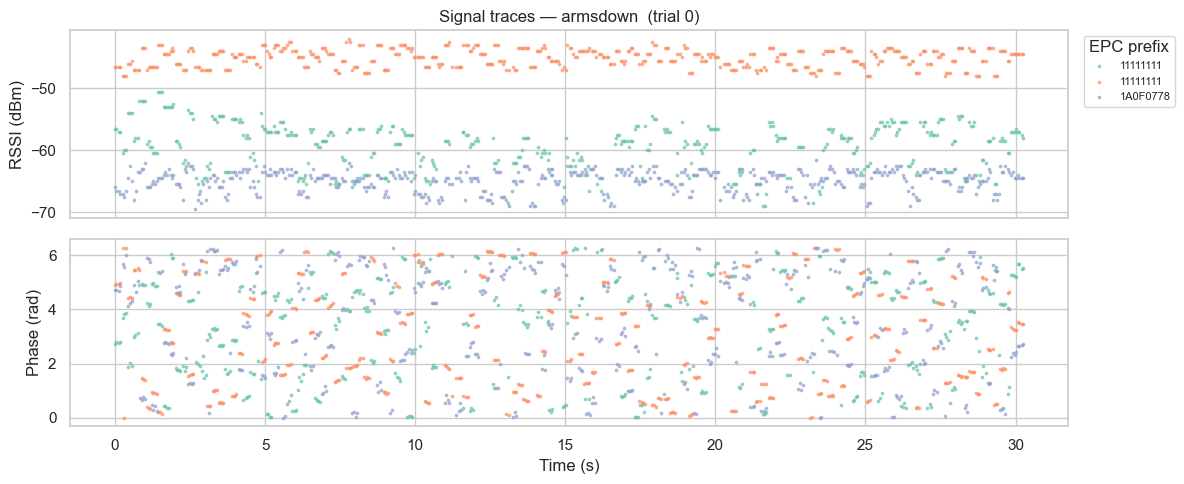

In [9]:
def plot_signal_traces(pose, trial_idx=0):
    tr_paths, te_path = split_pose_files(pose)
    path = te_path if trial_idx == TEST_FILE_INDEX else tr_paths[trial_idx]
    df   = load_rfid_csv(path)
    tags = sorted(df["EPC"].unique())
    t0   = df["Timestamp"].iloc[0]
    df["t_sec"] = (df["Timestamp"] - t0).dt.total_seconds()

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    for tag in tags:
        sub = df[df["EPC"] == tag]
        axes[0].scatter(sub["t_sec"], sub["RSSI"], s=3, label=tag[:8], alpha=0.6)
        axes[1].scatter(sub["t_sec"], sub["PhaseAngle"].dropna(),
                        s=3, label=tag[:8], alpha=0.6)
    axes[0].set_ylabel("RSSI (dBm)")
    axes[1].set_ylabel("Phase (rad)")
    axes[1].set_xlabel("Time (s)")
    axes[0].set_title(f"Signal traces — {pose}  (trial {trial_idx})")
    axes[0].legend(title="EPC prefix", bbox_to_anchor=(1.01, 1),
                   loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_signal_traces(POSES[0], trial_idx=0)

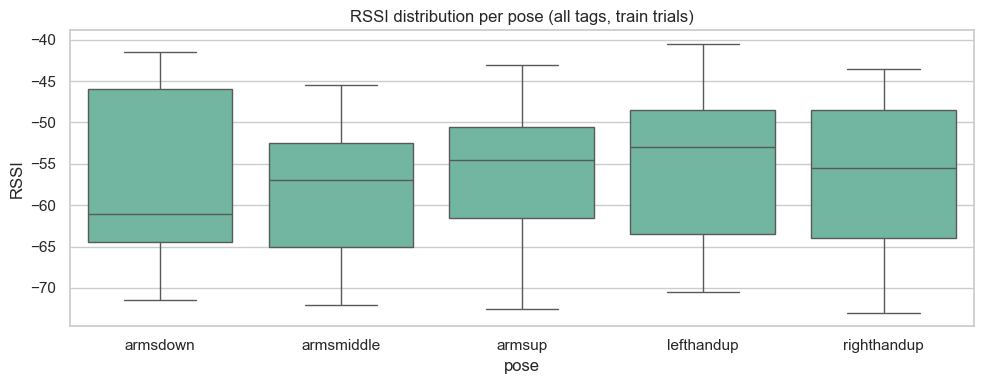

In [10]:
# RSSI distribution per pose (all train trials, all tags)
rows = []
for pose in POSES:
    try:
        tr_paths, _ = split_pose_files(pose)
    except FileNotFoundError:
        continue
    for p in tr_paths:
        df = load_rfid_csv(p)
        rows.extend(zip([pose] * len(df), df["RSSI"].values))

rssi_df = pd.DataFrame(rows, columns=["pose", "RSSI"])
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=rssi_df, x="pose", y="RSSI", ax=ax)
ax.set_title("RSSI distribution per pose (all tags, train trials)")
plt.tight_layout()
plt.show()

## 6 · Cross-Validation on Training Set

In [11]:
classifiers = {
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=4,
            random_state=RANDOM_STATE))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                    class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64), activation="relu",
            max_iter=500, random_state=RANDOM_STATE))
    ]),
}

# 4 train trials per pose -> 4-fold CV so each fold trains on 3, validates on 1
N_SPLITS = 4
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print(f"{'Model':<22} {'CV mean acc':>12} {'+-std':>8}")
print("-" * 44)
for name, pipe in classifiers.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():>12.3f} {scores.std():>8.3f}")

Model                   CV mean acc    +-std
--------------------------------------------
RandomForest                  0.944    0.013
GradientBoosting              0.946    0.030
SVM (RBF)                     0.970    0.008
MLP                           0.941    0.015


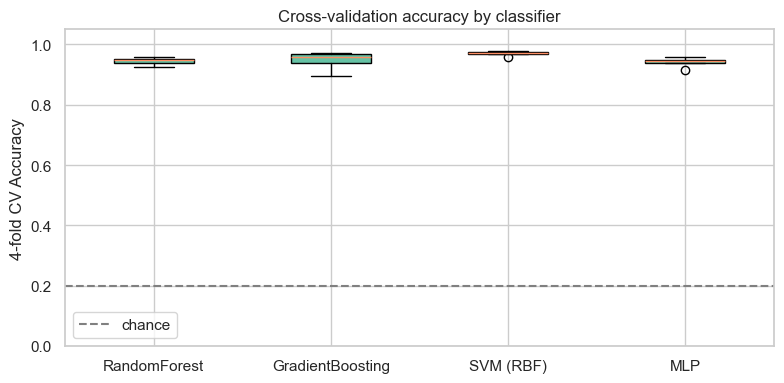

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_results[n] for n in cv_results], labels=list(cv_results.keys()),
           patch_artist=True)
ax.set_ylabel(f"{N_SPLITS}-fold CV Accuracy")
ax.set_title("Cross-validation accuracy by classifier")
ax.set_ylim(0, 1.05)
ax.axhline(1 / len(POSES), ls="--", color="grey", label="chance")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Train Final Model & Evaluate on Held-Out Test Trial

In [13]:
best_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"Best CV model : {best_name}  (mean acc = {cv_results[best_name].mean():.3f})")

best_pipe = classifiers[best_name]
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\nTest accuracy : {acc:.3f}  ({acc*100:.1f}%)")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best CV model : SVM (RBF)  (mean acc = 0.970)

Test accuracy : 0.819  (81.9%)

Classification report:
              precision    recall  f1-score   support

    armsdown       0.81      1.00      0.89        29
  armsmiddle       0.87      0.93      0.90        29
      armsup       0.69      0.79      0.73        28
  lefthandup       1.00      0.76      0.86        29
 righthandup       0.78      0.62      0.69        29

    accuracy                           0.82       144
   macro avg       0.83      0.82      0.82       144
weighted avg       0.83      0.82      0.82       144



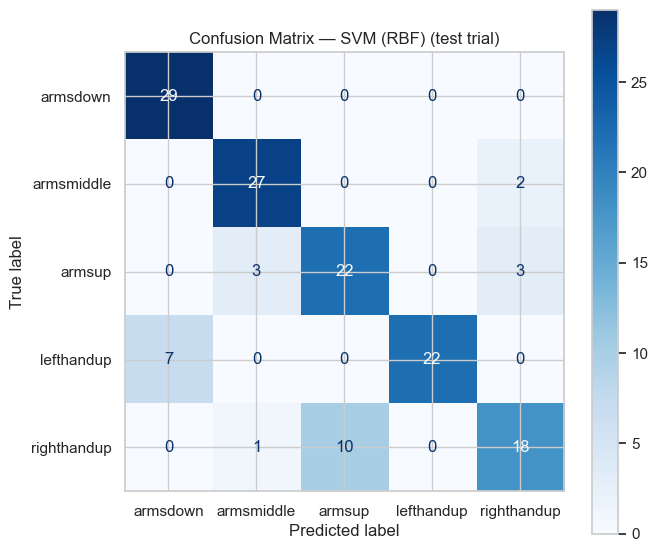

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name} (test trial)")
plt.tight_layout()
plt.show()

## 8 · Feature Importance

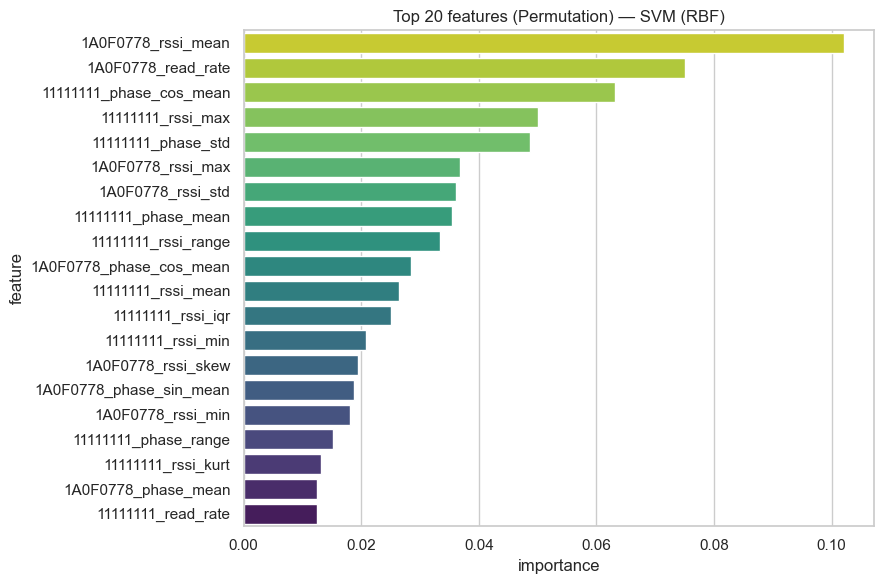

                feature  importance
     1A0F0778_rssi_mean    0.102083
     1A0F0778_read_rate    0.075000
11111111_phase_cos_mean    0.063194
      11111111_rssi_max    0.050000
     11111111_phase_std    0.048611
      1A0F0778_rssi_max    0.036806
      1A0F0778_rssi_std    0.036111
    11111111_phase_mean    0.035417
    11111111_rssi_range    0.033333
1A0F0778_phase_cos_mean    0.028472


In [15]:
clf_step = best_pipe.named_steps["clf"]

if hasattr(clf_step, "feature_importances_"):
    importances = clf_step.feature_importances_
    imp_source  = "MDI (impurity)"
else:
    perm = permutation_importance(
        best_pipe, X_test, y_test,
        n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    importances = perm.importances_mean
    imp_source  = "Permutation"

imp_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})\
           .sort_values("importance", ascending=False)

TOP_N = min(20, len(FEATURE_COLS))
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df.head(TOP_N), x="importance", y="feature",
            ax=ax, palette="viridis_r")
ax.set_title(f"Top {TOP_N} features ({imp_source}) — {best_name}")
plt.tight_layout()
plt.show()

print(imp_df.head(10).to_string(index=False))

## 9 · Per-Pose Signal Feature Heatmap

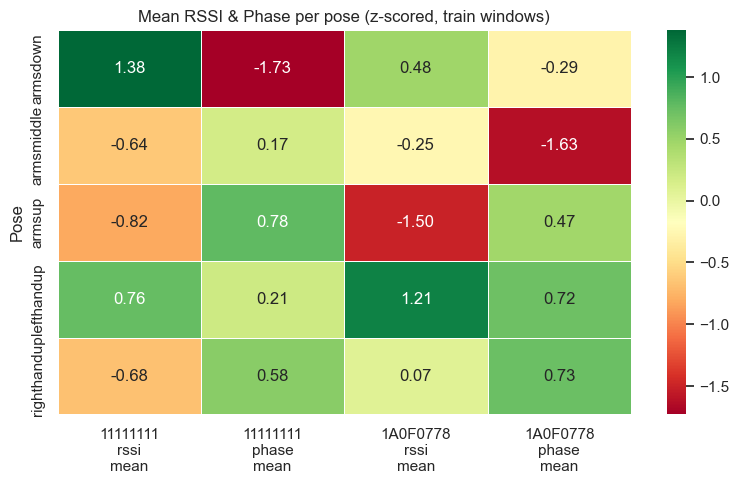

In [16]:
mean_feats   = train_df.groupby("label")[FEATURE_COLS].mean()
heatmap_cols = [c for c in FEATURE_COLS if "rssi_mean" in c or "phase_mean" in c]
hm_data      = mean_feats[heatmap_cols]
hm_norm      = (hm_data - hm_data.mean()) / (hm_data.std() + 1e-9)

fig, ax = plt.subplots(figsize=(max(8, len(heatmap_cols) * 0.9), 5))
sns.heatmap(hm_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax,
            xticklabels=[c.replace("_", "\n") for c in heatmap_cols])
ax.set_title("Mean RSSI & Phase per pose (z-scored, train windows)")
ax.set_ylabel("Pose")
plt.tight_layout()
plt.show()

## 10 · Save the Model

In [17]:
import joblib, json

MODEL_PATH = Path("rfid_pose_classifier.joblib")
META_PATH  = Path("rfid_pose_classifier_meta.json")

joblib.dump(best_pipe, MODEL_PATH)

meta = {
    "model"         : best_name,
    "classes"       : le.classes_.tolist(),
    "feature_cols"  : FEATURE_COLS,
    "canonical_tags": CANONICAL_TAGS,
    "window_sec"    : WINDOW_SEC,
    "step_sec"      : STEP_SEC,
    "test_accuracy" : round(float(acc), 4),
}
META_PATH.write_text(json.dumps(meta, indent=2))

print(f"Model saved -> {MODEL_PATH}")
print(f"Meta  saved -> {META_PATH}")
print(json.dumps(meta, indent=2))

Model saved -> rfid_pose_classifier.joblib
Meta  saved -> rfid_pose_classifier_meta.json
{
  "model": "SVM (RBF)",
  "classes": [
    "armsdown",
    "armsmiddle",
    "armsup",
    "lefthandup",
    "righthandup"
  ],
  "feature_cols": [
    "11111111_rssi_mean",
    "11111111_rssi_std",
    "11111111_rssi_min",
    "11111111_rssi_max",
    "11111111_rssi_range",
    "11111111_rssi_iqr",
    "11111111_rssi_skew",
    "11111111_rssi_kurt",
    "11111111_read_rate",
    "11111111_phase_mean",
    "11111111_phase_std",
    "11111111_phase_range",
    "11111111_phase_sin_mean",
    "11111111_phase_cos_mean",
    "1A0F0778_rssi_mean",
    "1A0F0778_rssi_std",
    "1A0F0778_rssi_min",
    "1A0F0778_rssi_max",
    "1A0F0778_rssi_range",
    "1A0F0778_rssi_iqr",
    "1A0F0778_rssi_skew",
    "1A0F0778_rssi_kurt",
    "1A0F0778_read_rate",
    "1A0F0778_phase_mean",
    "1A0F0778_phase_std",
    "1A0F0778_phase_range",
    "1A0F0778_phase_sin_mean",
    "1A0F0778_phase_cos_mean"
  ],
  "canoni

## 11 · Inference Helper

Use this to classify any new Impinj recording without re-training.

In [18]:
def predict_csv(csv_path,
                model_path=MODEL_PATH,
                meta_path=META_PATH):
    """
    Classify a new Impinj CSV file window-by-window.
    Returns a DataFrame: window_idx | window_start_s | predicted_pose | prob_<pose>...
    """
    pipe = joblib.load(model_path)
    meta = json.loads(Path(meta_path).read_text())

    df      = load_rfid_csv(csv_path)
    feat_df = extract_windows(df, label="unknown",
                               window_sec=meta["window_sec"],
                               step_sec=meta["step_sec"],
                               known_tags=meta["canonical_tags"])

    X     = feat_df[meta["feature_cols"]].values.astype(float)
    preds = pipe.predict(X)

    out = pd.DataFrame({
        "window_idx"    : range(len(preds)),
        "window_start_s": [i * meta["step_sec"] for i in range(len(preds))],
        "predicted_pose": [meta["classes"][p] for p in preds],
    })
    if hasattr(pipe, "predict_proba"):
        for i, cls in enumerate(meta["classes"]):
            out[f"prob_{cls}"] = pipe.predict_proba(X)[:, i]

    return out


# Uncomment to classify a new file:
# result = predict_csv("data/armsup/new_recording.csv")
# print(result)
# print("Majority vote:", result["predicted_pose"].mode()[0])
print("predict_csv() helper ready.")

predict_csv() helper ready.


---
## Summary

| Step | Detail |
|------|--------|
| **Hardware** | Impinj Speedway R420, 1 antenna, 3 passive UHF body-worn tags |
| **Signals** | RSSI (dBm), Phase Angle (rad) |
| **Features** | 14 stats x 3 tags = **42 features** per window |
| **Window** | 2 s, 50% overlap (1 s step) |
| **Data layout** | 5 files per pose; files 1-4 = train, file 5 = test |
| **CV** | 4-fold stratified on training windows |

### Troubleshooting tips
- **`lefthandup` vs `righthandup` confused** — asymmetry should appear in per-tag `read_rate` and `rssi_mean`. Check the heatmap. If both wrist tags look identical, the tag placement may be too symmetric.
- **Low test accuracy vs CV accuracy** — likely cross-trial drift. Try normalising RSSI per-trial (subtract trial mean) inside `extract_windows`.
- **Tag missing from a window** — currently zero-filled. For a more robust fix, impute with the trial-level median before windowing.
- **Different test file?** — change `TEST_FILE_INDEX` in the config cell (e.g. `0` = first, `2` = middle) and re-run from cell 4.